✅ Library siap!
✅ Data berhasil dimuat dari: /kaggle/input/datasets/dwifarhan/health-workers-central-java-2022/nakes_jateng_clean.csv
   Jumlah daerah : 35
   Jumlah kolom  : 10



,TIPE,KABUPATEN_KOTA,JUMLAH_PENDUDUK,JUMLAH_TENAGA_GIZI,JUMLAH_TENAGA_FARMASI,JUMLAH_BIDAN,JUMLAH_PERAWAT,JUMLAH_DOKTER_GIGI,JUMLAH_DOKTER_SPESIALIS,JUMLAH_DOKTER_UMUM
0,Kab,Kab.Cilacap,1988622,93,369,1264,2140,58,107,289
1,Kab,Kab.Banyumas,1806013,157,566,1325,3558,128,349,566
2,Kab,Kab.Purbalingga,1019840,58,264,733,1355,36,52,180
3,Kab,Kab.Banjarnegara,1038718,97,225,796,1071,46,44,150
4,Kab,Kab.Kebumen,1376825,93,438,1244,1965,60,114,299


1️⃣  Total Tenaga Kesehatan : 124,757 orang
2️⃣  Total Penduduk         : 37,032,410 jiwa
3️⃣  Total Kabupaten/Kota   : 35 daerah
     - Kabupaten            : 29
     - Kota                 : 6
4️⃣  Rata-rata Dokter Umum  : 309.14 per daerah

5️⃣  Daerah rasio dokter mencukupi (≥1 per 1000 penduduk):
    ✅ Kota Surakarta         rasio: 1.648
    ✅ Kota Magelang          rasio: 1.479
    ✅ Kota Semarang          rasio: 1.283

6️⃣  Jumlah daerah mencukupi: 3 dari 35 (8.6%)

7️⃣  Dokter Spesialis di Kota-kota:
    🏥 Kota Semarang         : 952 spesialis
    🏥 Kota Surakarta        : 686 spesialis
    🏥 Kota Magelang         : 135 spesialis
    🏥 Kota Salatiga         : 88 spesialis
    🏥 Kota Tegal            : 60 spesialis
    🏥 Kota Pekalongan       : 59 spesialis


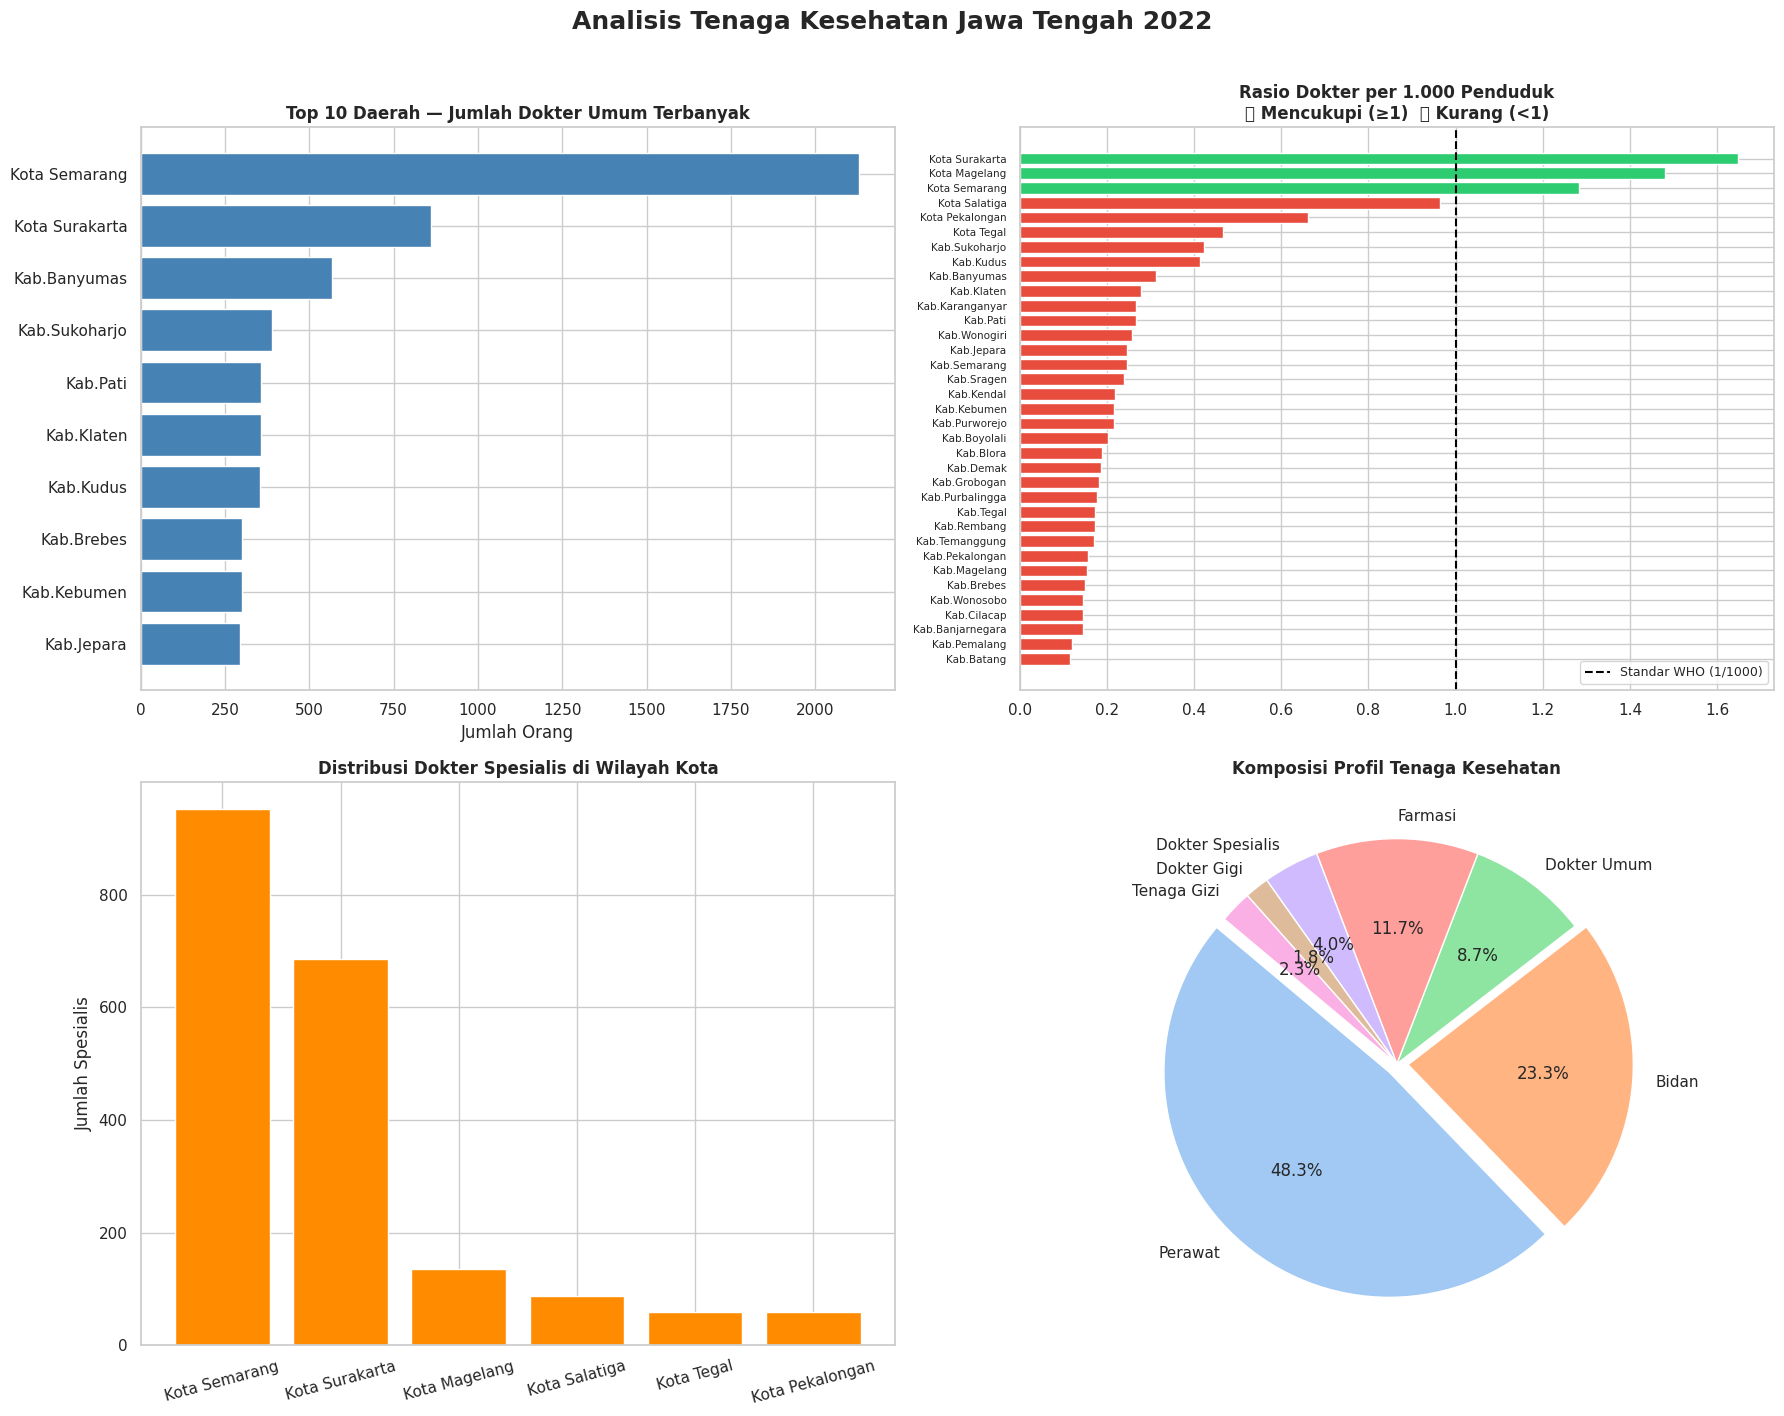

✅ Chart baru yang rapi tersimpan sebagai chart_nakes_jateng.png


In [1]:
# ============================================
# CELL 1 — Install & Import Library
# ============================================
!pip install pandas matplotlib seaborn --quiet

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Library siap!")

# ============================================
# CELL 2 — Auto-Load Data (Kaggle & Colab Friendly)
# ============================================
# Skrip pintar untuk mencari file otomatis di Kaggle maupun Colab
nama_target = 'nakes_jateng_clean.csv'
path_file = nama_target # Default untuk Colab jika langsung di-upload

if not os.path.exists(path_file):
    # Jika tidak ada di root (Colab), cari otomatis di folder input Kaggle
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if nama_target in filename:
                path_file = os.path.join(dirname, filename)
                break

try:
    df = pd.read_csv(path_file)
    print(f"✅ Data berhasil dimuat dari: {path_file}")
    print(f"   Jumlah daerah : {len(df)}")
    print(f"   Jumlah kolom  : {len(df.columns)}\n")
    display(df.head())
except Exception as e:
    print(f"❌ File '{nama_target}' tidak ditemukan. Pastikan sudah di-upload ke Kaggle/Colab! Error: {e}")

# ============================================
# CELL 3 — Jawab 7 Pertanyaan
# ============================================
if 'df' in locals():
    # Q1: Total Tenaga Kesehatan
    nakes_cols = ['JUMLAH_TENAGA_GIZI','JUMLAH_TENAGA_FARMASI','JUMLAH_BIDAN',
                  'JUMLAH_PERAWAT','JUMLAH_DOKTER_GIGI',
                  'JUMLAH_DOKTER_SPESIALIS','JUMLAH_DOKTER_UMUM']
    df['TOTAL_NAKES'] = df[nakes_cols].sum(axis=1)
    print(f"1️⃣  Total Tenaga Kesehatan : {int(df['TOTAL_NAKES'].sum()):,} orang")

    # Q2: Total Penduduk
    print(f"2️⃣  Total Penduduk         : {int(df['JUMLAH_PENDUDUK'].sum()):,} jiwa")

    # Q3: Total Kabupaten/Kota
    print(f"3️⃣  Total Kabupaten/Kota   : {len(df)} daerah")
    print(f"     - Kabupaten            : {len(df[df['TIPE']=='Kab'])}")
    print(f"     - Kota                 : {len(df[df['TIPE']=='Kota'])}")

    # Q4: Rata-rata Dokter Umum
    print(f"4️⃣  Rata-rata Dokter Umum  : {df['JUMLAH_DOKTER_UMUM'].mean():.2f} per daerah")

    # Q5 & Q6: Rasio Dokter
    df['RASIO_DOKTER'] = (df['JUMLAH_DOKTER_UMUM'] / df['JUMLAH_PENDUDUK']) * 1000
    cukup = df[df['RASIO_DOKTER'] >= 1].sort_values('RASIO_DOKTER', ascending=False)
    
    print(f"\n5️⃣  Daerah rasio dokter mencukupi (≥1 per 1000 penduduk):")
    for _, r in cukup.iterrows():
        print(f"    ✅ {r['KABUPATEN_KOTA']:<22} rasio: {r['RASIO_DOKTER']:.3f}")

    print(f"\n6️⃣  Jumlah daerah mencukupi: {len(cukup)} dari {len(df)} ({len(cukup)/len(df)*100:.1f}%)")

    # Q7: Dokter Spesialis di Kota
    kota = df[df['TIPE']=='Kota'].sort_values('JUMLAH_DOKTER_SPESIALIS', ascending=False)
    print(f"\n7️⃣  Dokter Spesialis di Kota-kota:")
    for _, r in kota.iterrows():
        print(f"    🏥 {r['KABUPATEN_KOTA']:<22}: {int(r['JUMLAH_DOKTER_SPESIALIS'])} spesialis")

# ============================================
# CELL 4 — Visualisasi 4 Chart (Sleek & No Overlap)
# ============================================
if 'df' in locals():
    sns.set_theme(style="whitegrid") # Bikin tema grafik lebih modern
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('Analisis Tenaga Kesehatan Jawa Tengah 2022', fontsize=18, fontweight='bold', y=1.01)

    # Chart 1: Top 10 Dokter Umum (Di-invert supaya peringkat 1 di atas)
    top10 = df.nlargest(10, 'JUMLAH_DOKTER_UMUM').sort_values('JUMLAH_DOKTER_UMUM', ascending=True)
    axes[0,0].barh(top10['KABUPATEN_KOTA'], top10['JUMLAH_DOKTER_UMUM'], color='steelblue')
    axes[0,0].set_title('Top 10 Daerah — Jumlah Dokter Umum Terbanyak', fontweight='bold')
    axes[0,0].set_xlabel('Jumlah Orang')

    # Chart 2: Rasio Dokter semua daerah (Font dikecilkan agar 35 daerah terbaca semua)
    df_sorted = df.sort_values('RASIO_DOKTER', ascending=True)
    colors = ['#2ecc71' if x >= 1 else '#e74c3c' for x in df_sorted['RASIO_DOKTER']]
    axes[0,1].barh(df_sorted['KABUPATEN_KOTA'], df_sorted['RASIO_DOKTER'], color=colors)
    axes[0,1].axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='Standar WHO (1/1000)')
    axes[0,1].set_title('Rasio Dokter per 1.000 Penduduk\n🟢 Mencukupi (≥1)  🔴 Kurang (<1)', fontweight='bold')
    axes[0,1].tick_params(axis='y', labelsize=7.5) # FIX: Biar nama kabupaten gak tabrakan
    axes[0,1].legend(fontsize=9, loc='lower right')

    # Chart 3: Spesialis di Kota (Rotasi diperbaiki)
    kota_sorted = df[df['TIPE']=='Kota'].sort_values('JUMLAH_DOKTER_SPESIALIS', ascending=False)
    axes[1,0].bar(kota_sorted['KABUPATEN_KOTA'], kota_sorted['JUMLAH_DOKTER_SPESIALIS'], color='darkorange')
    axes[1,0].set_title('Distribusi Dokter Spesialis di Wilayah Kota', fontweight='bold')
    axes[1,0].set_ylabel('Jumlah Spesialis')
    axes[1,0].tick_params(axis='x', rotation=15) # FIX: Kemiringan teks pas

    # Chart 4: Pie komposisi
    pie_data = {
        'Perawat': df['JUMLAH_PERAWAT'].sum(),
        'Bidan': df['JUMLAH_BIDAN'].sum(),
        'Dokter Umum': df['JUMLAH_DOKTER_UMUM'].sum(),
        'Farmasi': df['JUMLAH_TENAGA_FARMASI'].sum(),
        'Dokter Spesialis': df['JUMLAH_DOKTER_SPESIALIS'].sum(),
        'Dokter Gigi': df['JUMLAH_DOKTER_GIGI'].sum(),
        'Tenaga Gizi': df['JUMLAH_TENAGA_GIZI'].sum()
    }
    # Dipisahkan sedikit potongan terbesarnya agar estetik
    explode = [0.05 if i < 2 else 0 for i in range(len(pie_data))] 
    axes[1,1].pie(pie_data.values(), labels=pie_data.keys(), autopct='%1.1f%%', 
                  startangle=140, colors=sns.color_palette('pastel'), explode=explode)
                  
    axes[1,1].set_title('Komposisi Profil Tenaga Kesehatan', fontweight='bold')

    plt.tight_layout()
    plt.savefig('chart_nakes_jateng.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Chart baru yang rapi tersimpan sebagai chart_nakes_jateng.png")